In [2]:
import matplotlib
import json
from pathlib import Path
import pandas as pd

In [19]:

def load_results(results_dir):
    results = []
    for path in Path(results_dir).glob("*.json"):
        stem = path.stem
        print(stem)
        args = stem.split("__")
        kwargs = {}

        for i in range(0, len(args), 2):
            kwargs[args[i]] = float(args[i+1].split("_")[0])
            break

        with open(results_dir/path, "rb") as f:
            data = json.load(f)
            kwargs.update(data)
        results.append(kwargs)
    return results


In [22]:
vanilla = pd.DataFrame.from_dict(load_results("/root/vllm_prefill/eval/end_to_end/results/vanilla"))
prefill = pd.DataFrame.from_dict(load_results("/root/vllm_prefill/eval/end_to_end/results/prefill"))

vanilla.head()
prefill.head()




qps__2_num_users__40_num_documents__5_user_history_mean__15000_user_history_std__3000_user_history_min__10_user_history_max__33000_document_length__150
qps__4_num_users__40_num_documents__5_user_history_mean__15000_user_history_std__3000_user_history_min__10_user_history_max__33000_document_length__150
qps__2_num_users__40_num_documents__5_user_history_mean__15000_user_history_std__3000_user_history_min__10_user_history_max__33000_document_length__150
qps__4_num_users__40_num_documents__5_user_history_mean__15000_user_history_std__3000_user_history_min__10_user_history_max__33000_document_length__150


,qps,date,backend,model_id,tokenizer_id,best_of,num_prompts,request_rate,burstiness,max_concurrency,...,std_ttft_ms,p99_ttft_ms,mean_tpot_ms,median_tpot_ms,std_tpot_ms,p99_tpot_ms,mean_itl_ms,median_itl_ms,std_itl_ms,p99_itl_ms
0,2.0,20250407-063528,vllm,meta-llama/Llama-3.1-8B-Instruct,meta-llama/Llama-3.1-8B-Instruct,1,1000,2.0,1.0,None,...,885.924279,4469.697371,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,20250407-063640,vllm,meta-llama/Llama-3.1-8B-Instruct,meta-llama/Llama-3.1-8B-Instruct,1,1000,4.0,1.0,None,...,10491.306998,49229.943102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


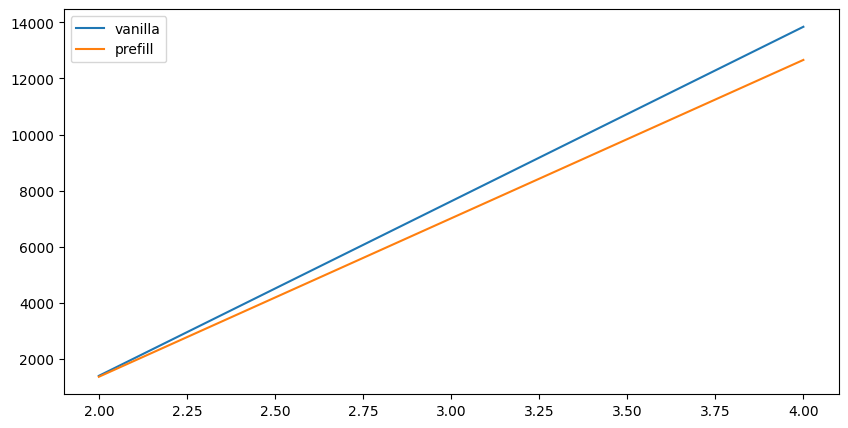

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(vanilla["qps"], vanilla["mean_ttft_ms"], label="vanilla")
ax.plot(prefill["qps"], prefill["mean_ttft_ms"], label="prefill")
ax.legend()


